# Iterative Feature Selection
I wanted to see if recursive elimination could still find the useful breast-cancer features after I mixed in 50 random noise columns. I kept the test split completely separate so the selector only learned from training data.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

## Data setup
I used the breast-cancer dataset and added fake columns on purpose. That made it easier to check whether the selector was learning signal or just reacting to extra dimensions.

In [2]:
rng = np.random.default_rng(42)
cancer = load_breast_cancer(as_frame=True)
X = cancer.data.copy()
y = cancer.target.copy()

noise = pd.DataFrame(
    rng.normal(size=(len(X), 50)),
    columns=[f"noise_{index:02d}" for index in range(50)],
    index=X.index,
)
X_w_noise = pd.concat([X, noise], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_w_noise,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

# I fit scaling on the training split first so the test set stays untouched.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

baseline_model = LogisticRegression(max_iter=5000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)
baseline_pred = baseline_model.predict(X_test_scaled)
baseline_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = pd.DataFrame(
    {
        'model': ['All features'],
        'selected_features': [X_train_scaled.shape[1]],
        'test_accuracy': [accuracy_score(y_test, baseline_pred)],
        'test_roc_auc': [roc_auc_score(y_test, baseline_prob)],
    }
).round(3)
display(baseline_metrics)
print(f'Train shape with noise: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}')

,model,selected_features,test_accuracy,test_roc_auc
0,All features,80,0.958,0.989


Train shape with noise: (426, 80), Test shape: (143, 80)


## Recursive elimination
I switched to `RFECV` here because it lets the model decide how many features to keep with cross-validation. That felt closer to the real question I had: how much signal is left after I remove the least useful columns step by step?

In [3]:
selector = RFECV(
    estimator=LogisticRegression(max_iter=5000, random_state=42),
    step=2,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    min_features_to_select=5,
    n_jobs=1,
)
selector.fit(X_train_scaled, y_train)

selected_features = X_train_scaled.columns[selector.support_].tolist()
X_train_selected = X_train_scaled.loc[:, selected_features]
X_test_selected = X_test_scaled.loc[:, selected_features]

selected_model = LogisticRegression(max_iter=5000, random_state=42)
selected_model.fit(X_train_selected, y_train)
selected_pred = selected_model.predict(X_test_selected)
selected_prob = selected_model.predict_proba(X_test_selected)[:, 1]

comparison = pd.DataFrame(
    [
        {
            'model': 'All features',
            'selected_features': X_train_scaled.shape[1],
            'test_accuracy': accuracy_score(y_test, baseline_pred),
            'test_roc_auc': roc_auc_score(y_test, baseline_prob),
        },
        {
            'model': 'RFECV logistic',
            'selected_features': len(selected_features),
            'test_accuracy': accuracy_score(y_test, selected_pred),
            'test_roc_auc': roc_auc_score(y_test, selected_prob),
        },
    ]
).round(3)
display(comparison)

selection_breakdown = pd.DataFrame(
    {
        'group': ['real features', 'noise features'],
        'selected_count': [
            sum(not name.startswith('noise_') for name in selected_features),
            sum(name.startswith('noise_') for name in selected_features),
        ],
    }
)
display(selection_breakdown)

print('Selected feature names:')
selected_features

,model,selected_features,test_accuracy,test_roc_auc
0,All features,80,0.958,0.989
1,RFECV logistic,5,0.958,0.996


,group,selected_count
0,real features,5
1,noise features,0


Selected feature names:


['radius error',
 'worst radius',
 'worst texture',
 'worst area',
 'worst concave points']

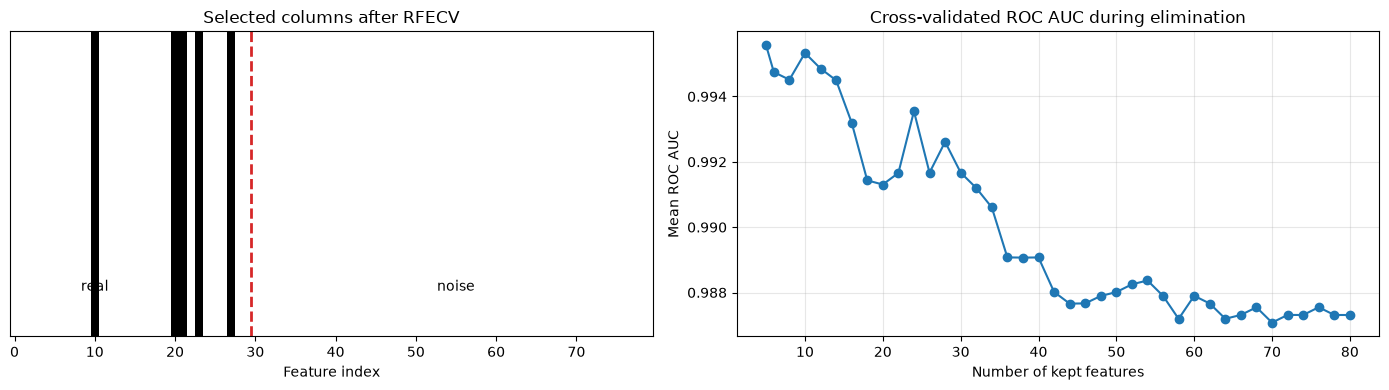

In [4]:
feature_counts = selector.cv_results_.get(
    'n_features',
    np.arange(len(selector.cv_results_['mean_test_score'])) + selector.min_features_to_select,
)
selection_mask = selector.support_.reshape(1, -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(selection_mask, cmap='gray_r', aspect='auto')
axes[0].set_title('Selected columns after RFECV')
axes[0].set_xlabel('Feature index')
axes[0].set_yticks([])
axes[0].axvline(len(cancer.feature_names) - 0.5, color='tab:red', linestyle='--', linewidth=2)
axes[0].text(10, 0.35, 'real', ha='center')
axes[0].text(55, 0.35, 'noise', ha='center')

axes[1].plot(feature_counts, selector.cv_results_['mean_test_score'], marker='o')
axes[1].set_title('Cross-validated ROC AUC during elimination')
axes[1].set_xlabel('Number of kept features')
axes[1].set_ylabel('Mean ROC AUC')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

,feature,coefficient,abs_coefficient
4,worst concave points,-2.586,2.586
1,worst radius,-1.884,1.884
3,worst area,-1.709,1.709
0,radius error,-1.357,1.357
2,worst texture,-1.355,1.355


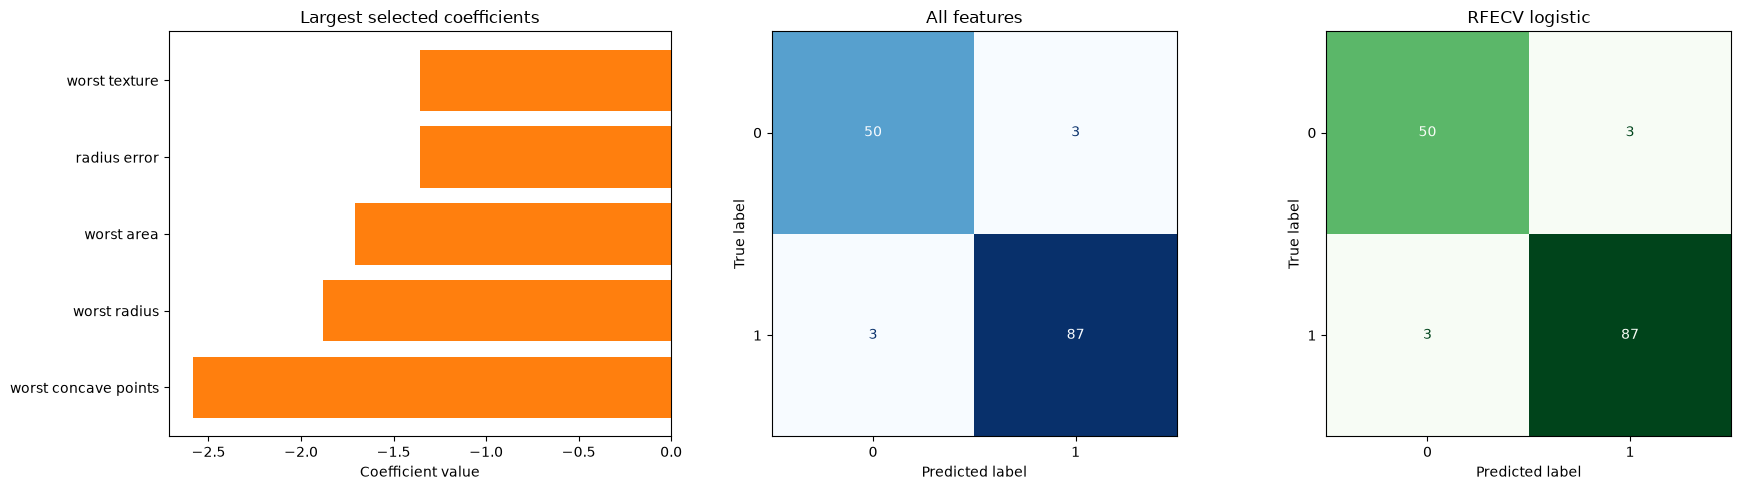

In [5]:
coefficient_frame = (
    pd.DataFrame(
        {
            'feature': selected_features,
            'coefficient': selected_model.coef_[0],
        }
    )
    .assign(abs_coefficient=lambda frame: frame['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
)
display(coefficient_frame.head(10).round(3))

# Large coefficients help me see which selected features are driving the boundary most strongly.
top_coefficients = coefficient_frame.head(12).sort_values('coefficient')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = np.where(top_coefficients['coefficient'] > 0, 'tab:blue', 'tab:orange')
axes[0].barh(top_coefficients['feature'], top_coefficients['coefficient'], color=colors)
axes[0].set_title('Largest selected coefficients')
axes[0].set_xlabel('Coefficient value')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_pred,
    cmap='Blues',
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title('All features')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    selected_pred,
    cmap='Greens',
    colorbar=False,
    ax=axes[2],
)
axes[2].set_title('RFECV logistic')
plt.tight_layout()
plt.show()

## What I learned
RFECV kept 5 of 80 columns on this split. It kept 5 real features and 0 noise features.

The baseline logistic model reached accuracy 0.958 and ROC AUC 0.989. After elimination, the smaller model reached accuracy 0.958 and ROC AUC 0.996. The strongest remaining coefficients were worst concave points, worst radius, worst area, which matches the features I usually see as important in this dataset.